<a href="https://colab.research.google.com/github/aaqhilahamed2004-ops/non-markovian_black-hole_evaporation/blob/main/MvNM_base_v5_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
!pip install qiskit qiskit-aer --quiet
from qiskit_aer import Aer
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace, entropy,Kraus
import numpy as np
backend = Aer.get_backend('statevector_simulator')

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace, entropy, Kraus
from qiskit_aer import AerSimulator

# -----------------------------
# PARAMETERS
# -----------------------------
N_BH = 10
N_ENV = 5
TOTAL_QUBITS = N_BH + N_ENV

# -----------------------------
# SCRAMBLING (chaotic dynamics)
# -----------------------------
def scramble_black_hole(qc, bh):
    LAYERS = 5
    for _ in range(LAYERS):

        # --- random single-qubit rotations (local chaos) ---
        # Using rx, ry, rz for diverse random single-qubit operations
        for q in bh:
            qc.rx(np.random.uniform(0, 2*np.pi), q)
            qc.ry(np.random.uniform(0, 2*np.pi), q)
            qc.rz(np.random.uniform(0, 2*np.pi), q)

        # --- diverse nearest-neighbour entanglement (local spreading) ---
        if len(bh) > 1:
            for i in range(len(bh)-1):
                qc.cx(bh[i], bh[i+1]) # Original CNOT
                qc.cz(bh[i], bh[i+1]) # Added CZ for more diversity
                qc.cy(bh[i+1], bh[i]) # Added CY with swapped control/target for diversity

        # --- diverse long-range entanglement (global scrambling) ---
        if len(bh) > 1: # Ensure there are at least 2 qubits for long-range interactions
            # Original long-range CZ pattern
            for i in range(len(bh)//2):
                qc.cz(bh[i], bh[-(i+1)])

            # Additional long-range connections
            if len(bh) > 3: # Need at least 4 qubits for these specific connections
                qc.cx(bh[0], bh[-1]) # CNOT between first and last qubit
                qc.cy(bh[1], bh[-2]) # CY between second and second-to-last
                qc.cz(bh[0], bh[-2]) # CZ between first and second-to-last

        # --- random SWAP layer (operator growth) ---
        # This helps in quickly spreading entanglement
        for i in range(0, len(bh)-1, 2):
            qc.swap(bh[i], bh[i+1])

# -----------------------------
# ENVIRONMENT DYNAMICS
# -----------------------------
def evolve_environment(qc, env):
    """
    Environment self-interaction (stores memory).
    Introduced more diverse and random operations for environment evolution.
    """
    if len(env) < 2:
        return

    for i in range(len(env)-1):
        qc.cx(env[i], env[i+1])
        qc.cz(env[i+1], env[i]) # Added CZ with reversed control and targets for more environmental entanglement
        qc.rx(np.random.uniform(0, 2*np.pi), env[i]) # Random angles
        qc.ry(np.random.uniform(0, 2*np.pi), env[i+1]) # Random angles
        qc.rz(np.random.uniform(0, 2*np.pi), env[i]) # Added RZ for more diversity


# -----------------------------
# BH-ENV COUPLING
# -----------------------------

def bh_environment_interaction(qc, bh, env):
    """Information exchange between system and bath"""
    for b in bh:
        for e in env:
            qc.cz(b, e)
            qc.rx(np.pi/8, b)
            qc.ry(np.pi/8, e)

# -----------------------------
# KRYLOV SPREAD COMPLEXITY LOGIC
# -----------------------------

# Krylov basis is built incrementally so we never reprocess past states.
_krylov_basis = []   # module-level cache; reset before each evaporation run

def _reset_krylov():
    global _krylov_basis
    _krylov_basis = []

def compute_spread_complexity(state_history):
    """
    Incremental Krylov (spread) complexity.
    Extends the Krylov basis by one vector per new state, then returns
    K(t) for every state in the history.  O(T) amortised per step.
    """
    global _krylov_basis

    # Extend basis with any states not yet processed
    for state in state_history[len(_krylov_basis):]:
        vec = np.array(state.data.flatten() if hasattr(state, 'data') else state.data,
                       dtype=complex)
        for b in _krylov_basis:
            vec -= np.vdot(b, vec) * b
        norm = np.linalg.norm(vec)
        if norm > 1e-10:
            _krylov_basis.append(vec / norm)

    # K(t) = Σ_n  n * |<K_n | ψ(t)>|²  for every state in history
    complexities = []
    for state in state_history:
        vec = np.array(state.data.flatten() if hasattr(state, 'data') else state.data,
                       dtype=complex)
        norm = np.linalg.norm(vec)
        if norm > 1e-12:
            vec = vec / norm
        k_t = sum(n * abs(np.vdot(b, vec))**2
                  for n, b in enumerate(_krylov_basis))
        complexities.append(k_t)

    return complexities

def compute_mutual_information(state, emitted_qubits, remaining_bh, env):
    """
    Computes I(R:BH) = S(R) + S(BH) - S(R u BH) at a given emission step.

    state         : current Statevector over all TOTAL_QUBITS
    emitted_qubits: list of qubit indices already emitted as radiation
    remaining_bh  : list of qubit indices still in the black hole
    env           : list of qubit indices in the environment
    """
    all_qubits = list(range(state.num_qubits))

    # S(R): trace out BH + ENV
    trace_out_for_R = remaining_bh + env
    rho_R = partial_trace(state, trace_out_for_R)
    S_R = entropy(rho_R, base=2)

    # S(BH): trace out R + ENV
    trace_out_for_BH = emitted_qubits + env
    rho_BH = partial_trace(state, trace_out_for_BH)
    S_BH = entropy(rho_BH, base=2)

    # S(R u BH): trace out only ENV
    rho_RuBH = partial_trace(state, env)
    S_RuBH = entropy(rho_RuBH, base=2)

    I_RBH = S_R + S_BH - S_RuBH
    return I_RBH, S_R, S_BH

# -----------------------------
# EVAPORATION MODELS
# -----------------------------

def run_markovian_evaporation():
    _reset_krylov()
    print("Starting Markovian Evaporation...")
    backend = AerSimulator(method='density_matrix')
    entropies, steps, state_history = [], [], []
    current_rho = DensityMatrix.from_label('0' * N_BH)

    remaining_bh_qubits = N_BH # Track number of actual BH qubits remaining

    # Initialize state_history with the initial black hole state
    state_history.append(current_rho)

    for step in range(1, N_BH + 1):
        if remaining_bh_qubits == 0: # Ensure we don't proceed if no BH qubits left
            break

        # Circuit for this step involves 'remaining_bh_qubits' BH qubits + 1 radiation qubit
        qc = QuantumCircuit(remaining_bh_qubits + 1)
        bh_indices_in_qc = list(range(remaining_bh_qubits)) # Indices for BH qubits within this qc
        rad_index_in_qc = remaining_bh_qubits # Index for the radiation qubit within this qc

        if remaining_bh_qubits > 1:
            scramble_black_hole(qc, bh_indices_in_qc)
        else:
            qc.u(np.pi/4, np.pi/2, np.pi/3, 0) # Apply to qubit 0 if only one BH qubit

        # Emission coupling (always between BH qubit 0 of current qc and the new rad qubit)
        qc.cx(0, rad_index_in_qc)
        qc.ry(np.pi/4, rad_index_in_qc)

        # Evolve the current_rho (representing 'remaining_bh_qubits' qubits)
        # with the new radiation qubit (initialized to |0>)
        rho_with_rad = current_rho.tensor(DensityMatrix.from_label('0'))

        # Evolve the combined state
        result_rho = rho_with_rad.evolve(transpile(qc, backend))

        # Compute entropy of the emitted radiation (trace out the BH part)
        S_R = entropy(partial_trace(result_rho, bh_indices_in_qc), base=2)

        entropies.append(S_R)

        # Update current_rho for the next step: trace out the *emitted* qubit (rad_index_in_qc)
        # to get the remaining BH qubits' state.
        current_rho = partial_trace(result_rho, [rad_index_in_qc])
        state_history.append(current_rho)

        # Calculate K(t) incrementally
        current_K = compute_spread_complexity(state_history)[-1]

        steps.append(step)

        # Decrement remaining_bh_qubits for the next iteration
        remaining_bh_qubits -= 1

        print(f"[Markovian] Step {step}/{N_BH} | S(R) = {S_R:.4f} | K(t) = {current_K:.4f}")
    return steps, entropies, state_history

def run_non_markovian_evaporation():
    _reset_krylov()
    print("Starting Non-Markovian Evaporation...")
    current_state = Statevector.from_label('0' * TOTAL_QUBITS)
    bh, env = list(range(N_BH)), list(range(N_BH, TOTAL_QUBITS))
    entropies, steps, state_history = [], [], []
    emitted_qubits = []
    mutual_info = []

    for step in range(1, N_BH + 1):
        step_qc = QuantumCircuit(TOTAL_QUBITS)
        scramble_black_hole(step_qc, bh)
        evolve_environment(step_qc, env)
        bh_environment_interaction(step_qc, bh, env)

        current_state = current_state.evolve(step_qc)
        state_history.append(current_state) # Track global statevector

        #Calculate S(R)
        emitted = bh.pop(0)
        emitted_qubits.append(emitted)
        I_RBH, _, _ = compute_mutual_information(current_state, emitted_qubits, bh, env)
        mutual_info.append(I_RBH)


        rho_R = partial_trace(current_state, bh + env)
        S_R = entropy(rho_R, base=2) # Define S_R here

        # Calculate K(t) incrementally
        current_K = compute_spread_complexity(state_history)[-1]

        entropies.append(S_R)
        steps.append(step)

        print(f"[Non-Markovian] Step {step}/{N_BH} | S(R) = {S_R:.4f} | K(t) = {current_K:.4f} | I(R:BH) = {I_RBH:.4f}")
    return steps, entropies, mutual_info, state_history

In [14]:
import numpy as np
# -----------------------------
# MAIN & PLOTTING
# -----------------------------

if __name__ == "__main__":
    s_m, ent_m, states_m = run_markovian_evaporation()
    s_nm, ent_nm, mutual_info_nm, states_nm = run_non_markovian_evaporation()

    dS_m = np.diff(ent_m)
    dS_nm = np.diff(ent_nm)

    _reset_krylov() # Reset Krylov basis before computing k_m
    k_m = compute_spread_complexity(states_m)

    _reset_krylov() # Reset Krylov basis before computing k_nm
    k_nm = compute_spread_complexity(states_nm)

Starting Markovian Evaporation...
[Markovian] Step 1/10 | S(R) = 1.0000 | K(t) = 1.0000
[Markovian] Step 2/10 | S(R) = 1.9961 | K(t) = 2.0000
[Markovian] Step 3/10 | S(R) = 2.9912 | K(t) = 3.0000
[Markovian] Step 4/10 | S(R) = 3.9792 | K(t) = 3.9997
[Markovian] Step 5/10 | S(R) = 4.9613 | K(t) = 4.9985
[Markovian] Step 6/10 | S(R) = 5.9176 | K(t) = 5.9932
[Markovian] Step 7/10 | S(R) = 6.8563 | K(t) = 6.9762
[Markovian] Step 8/10 | S(R) = 7.6904 | K(t) = 7.9194
[Markovian] Step 9/10 | S(R) = 8.3449 | K(t) = 8.7854
[Markovian] Step 10/10 | S(R) = 8.7621 | K(t) = 9.3207
Starting Non-Markovian Evaporation...
[Non-Markovian] Step 1/10 | S(R) = 0.9997 | K(t) = 0.0000 | I(R:BH) = 1.8692
[Non-Markovian] Step 2/10 | S(R) = 1.9989 | K(t) = 1.0000 | I(R:BH) = 3.6539
[Non-Markovian] Step 3/10 | S(R) = 2.9976 | K(t) = 2.0000 | I(R:BH) = 4.6608
[Non-Markovian] Step 4/10 | S(R) = 3.9939 | K(t) = 2.9999 | I(R:BH) = 4.9242
[Non-Markovian] Step 5/10 | S(R) = 4.9766 | K(t) = 3.9997 | I(R:BH) = 4.9754
[N

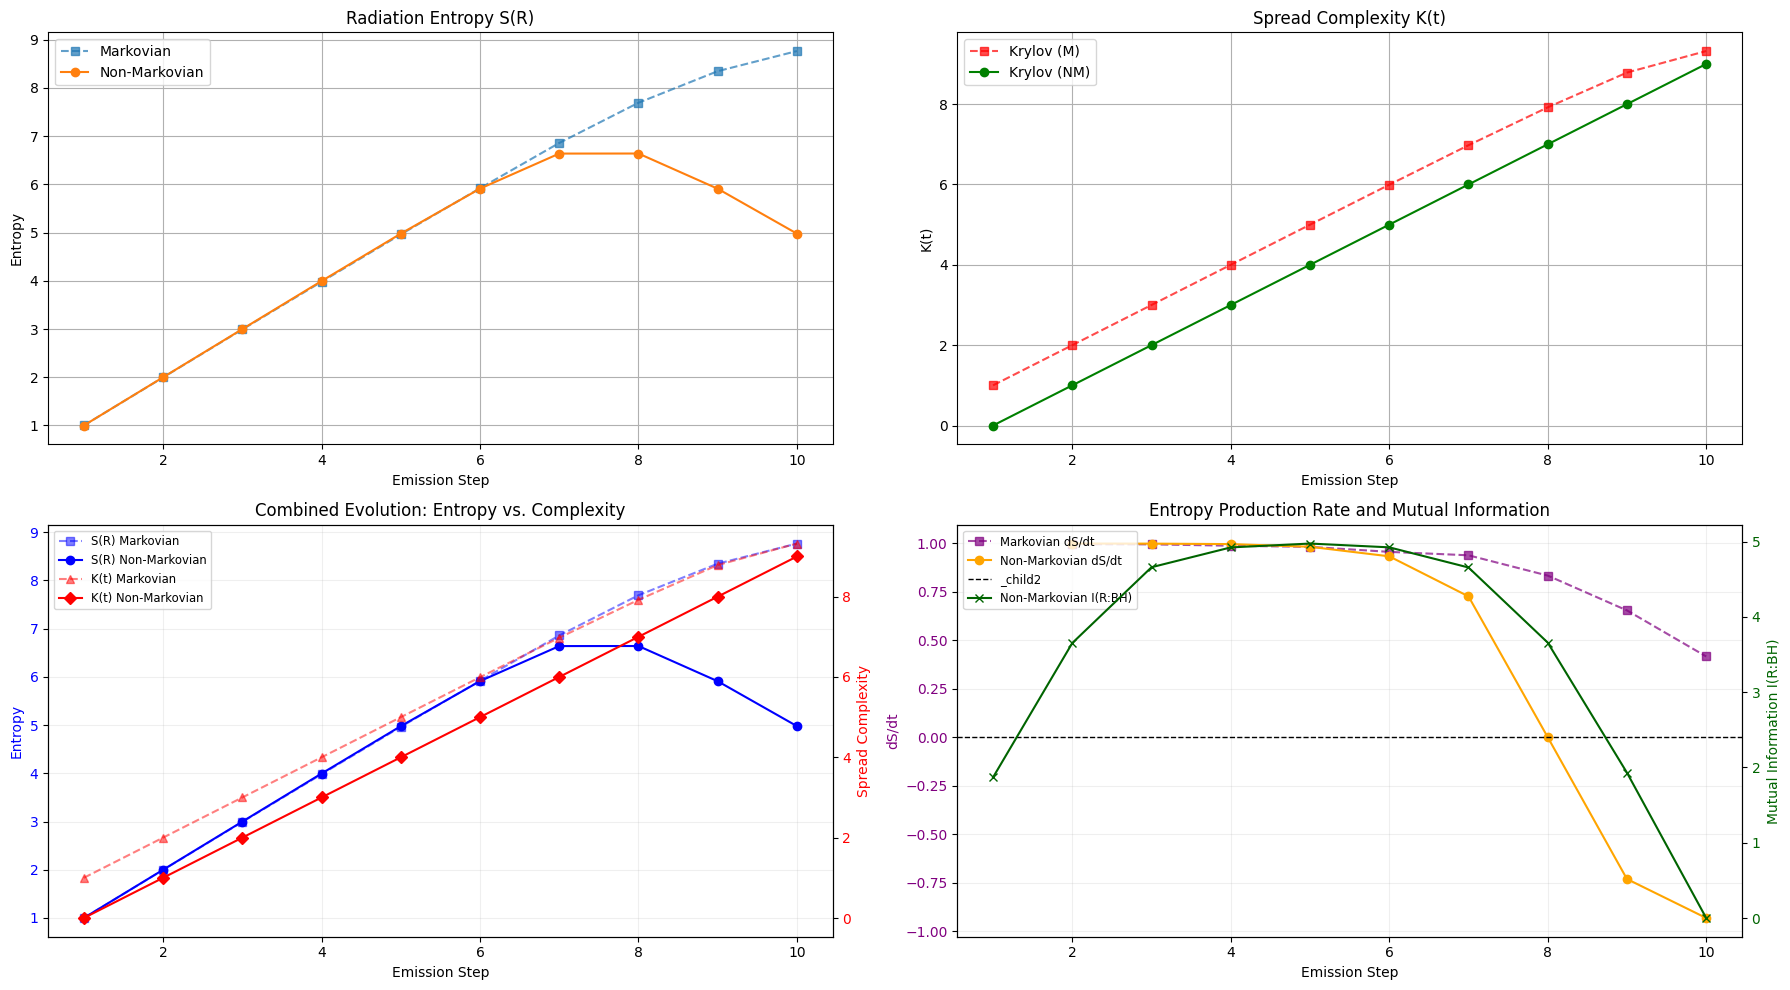


Estimated Page Time (first step where I(R:BH) > 0.1): 1 emission steps


In [15]:
# Visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Plot 1: S(R) vs Steps (The Page Curve)
axes[0, 0].plot(s_m, ent_m, 's--', label="Markovian", alpha=0.7)
axes[0, 0].plot(s_nm, ent_nm, 'o-', label="Non-Markovian")
axes[0, 0].set_title("Radiation Entropy S(R)")
axes[0, 0].set_xlabel("Emission Step"); axes[0, 0].set_ylabel("Entropy"); axes[0, 0].legend(); axes[0, 0].grid()

# Plot 2: K(t) vs Steps (Growth of Chaos)
axes[0, 1].plot(s_m, k_m[1:], 's--', color='red', label="Krylov (M)", alpha=0.7)
axes[0, 1].plot(s_nm, k_nm, 'o-', color='green', label="Krylov (NM)")
axes[0, 1].set_title("Spread Complexity K(t)")
axes[0, 1].set_xlabel("Emission Step"); axes[0, 1].set_ylabel("K(t)"); axes[0, 1].legend(); axes[0, 1].grid()

# Plot 3: THE "FOUR CURVES" COMPARISON (Dual Axis)
# This shows how S and K behave simultaneously
ax_ent = axes[1, 0]
ax_comp = ax_ent.twinx()

# Plot Entropies on the left axis (Blue shades)
l1, = ax_ent.plot(s_m, ent_m, 's--', color='blue', label="S(R) Markovian", alpha=0.5)
l2, = ax_ent.plot(s_nm, ent_nm, 'o-', color='blue', label="S(R) Non-Markovian")
ax_ent.set_ylabel("Entropy", color='blue')
ax_ent.tick_params(axis='y', labelcolor='blue')

# Plot Complexities on the right axis (Red/Orange shades)
l3, = ax_comp.plot(s_m, k_m[1:], '^--', color='red', label="K(t) Markovian", alpha=0.5)
l4, = ax_comp.plot(s_nm, k_nm, 'D-', color='red', label="K(t) Non-Markovian")
ax_comp.set_ylabel("Spread Complexity", color='red')
ax_comp.tick_params(axis='y', labelcolor='red')

# Unified Legend for the four curves
lines = [l1, l2, l3, l4]
labels = [line.get_label() for line in lines]
ax_ent.legend(lines, labels, loc='upper left', fontsize='small')
ax_ent.set_title("Combined Evolution: Entropy vs. Complexity")
ax_ent.set_xlabel("Emission Step"); ax_ent.grid(True, alpha=0.2)

# Plot 4: Entropy Production Rate and Mutual Information (NEW)
ax_ds = axes[1, 1]
ax_mi = ax_ds.twinx()

ax_ds.plot(s_m[1:], dS_m, 's--', color='purple', label="Markovian dS/dt", alpha=0.7)
ax_ds.plot(s_nm[1:], dS_nm, 'o-', color='orange', label="Non-Markovian dS/dt")
ax_ds.axhline(0, color='black', lw=1, ls='--')
ax_ds.set_ylabel("dS/dt", color='purple')
ax_ds.tick_params(axis='y', labelcolor='purple')

l_mi, = ax_mi.plot(s_nm, mutual_info_nm, 'x-', color='darkgreen', label="Non-Markovian I(R:BH)")
ax_mi.set_ylabel("Mutual Information I(R:BH)", color='darkgreen')
ax_mi.tick_params(axis='y', labelcolor='darkgreen')

# Combine legends for the last plot
lines_last_plot = ax_ds.get_lines() + [l_mi]
labels_last_plot = [line.get_label() for line in lines_last_plot]
ax_ds.legend(lines_last_plot, labels_last_plot, loc='upper left', fontsize='small')
ax_ds.set_title("Entropy Production Rate and Mutual Information")
ax_ds.set_xlabel("Emission Step"); ax_ds.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# Extract Page Time from I(R:BH)
# The Page time is approximately where I(R:BH) starts to increase significantly
# We'll define it as the first step where I(R:BH) is greater than a small threshold
page_time_idx = np.where(np.array(mutual_info_nm) > 0.1)[0] # Threshold of 0.1 for significant rise
if len(page_time_idx) > 0:
    page_time = s_nm[page_time_idx[0]]
    print(f"\nEstimated Page Time (first step where I(R:BH) > 0.1): {page_time} emission steps")
else:
    print("\nCould not determine Page Time (I(R:BH) did not exceed threshold).")


## C1 — BLP Non-Markovianity Measure

Demonstrates directly that the circuit produces non-Markovian dynamics in the Breuer–Laine–Piilo sense by computing trace-distance revivals between two probe states.

Computing BLP measure  (N_BH=10, N_ENV=5)...
Probe 1: |0>^N_BH   Probe 2: |+>|0>^(N_BH-1)
Both runs use seed=42 — identical random angles isolate memory effects.

Trace distances D(t):
  Step 1: D = 0.008784
  Step 2: D = 0.005167
  Step 3: D = 0.003640
  Step 4: D = 0.003335
  Step 5: D = 0.003514
  Step 6: D = 0.007634
  Step 7: D = 0.006310
  Step 8: D = 0.006748
  Step 9: D = 0.003629
  Step 10: D = 0.002917

BLP measure  N_BLP = 0.004737
→ N_BLP > 0 — CONFIRMED non-Markovian (BLP criterion satisfied).
  Trace-distance revivals demonstrate information backflow from ENV.


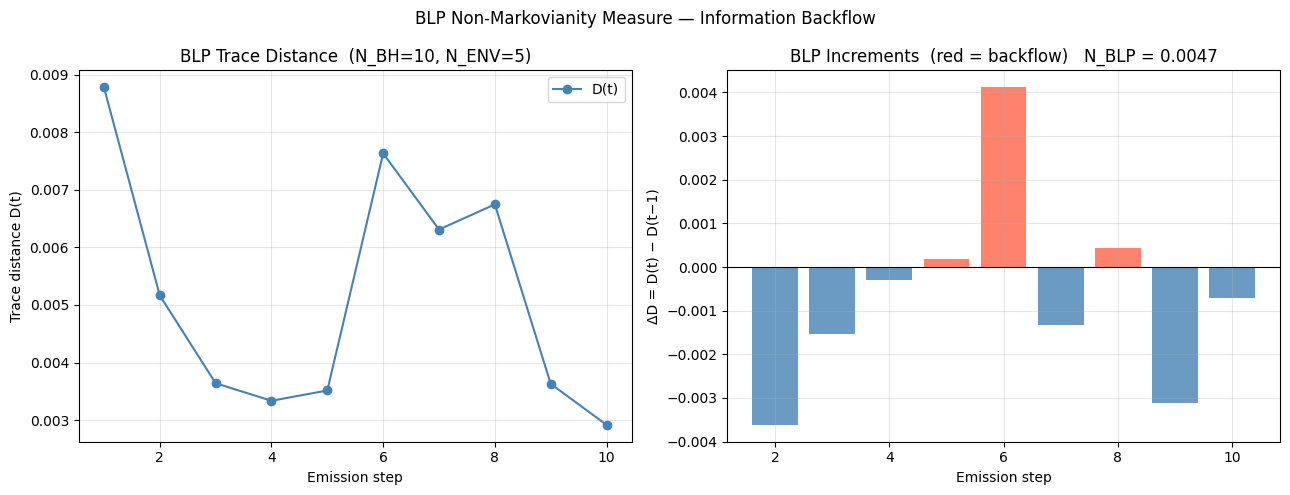

Saved: blp_measure.pdf


In [16]:
# =============================================================================
# BLP NON-MARKOVIANITY MEASURE  (addresses Reviewer C1)
# =============================================================================
# BLP (Breuer, Laine & Piilo 2009): non-Markovianity = total increase in
# trace distance D(rho1, rho2) between two probe states over time.
# Strictly Markovian channels contract trace distance monotonically;
# any revival (dD/dt > 0) unambiguously signals environmental memory.
#
# RAM fix: each step evolves only new gates via state.evolve(sub_qc),
# carrying the statevector forward instead of re-simulating an ever-growing
# accumulated circuit from scratch (which caused OOM at step ~8).
# =============================================================================

def trace_distance(rho1, rho2) -> float:
    """D(rho1,rho2) = (1/2)*Tr|rho1-rho2| via eigenvalues of Hermitian diff."""
    eigvals = np.linalg.eigvalsh(rho1.data - rho2.data)
    return 0.5 * np.sum(np.abs(eigvals))


def run_evaporation_for_blp(probe: str, seed: int = 42):
    """
    Step-by-step non-Markovian evaporation using statevector.evolve().
    No gate accumulation — each step builds a fresh sub-circuit.

    probe : 'zero'  -> BH starts in |0...0>
            'plus'  -> BH starts in |+>|0...0>  (first qubit in |+>)

    Returns: list of single-qubit DensityMatrix for bh[0] at each step.
    """
    np.random.seed(seed)

    if probe == 'plus':
        bh_sv = Statevector.from_label('+' + '0' * (N_BH - 1))
    else:
        bh_sv = Statevector.from_label('0' * N_BH)

    state = bh_sv.expand(Statevector.from_label('0' * N_ENV))

    bh  = list(range(N_BH))
    env = list(range(N_BH, TOTAL_QUBITS))
    rho_series = []

    while len(bh) > 0:
        sub = QuantumCircuit(TOTAL_QUBITS)
        scramble_black_hole(sub, bh)
        evolve_environment(sub, env)
        bh_environment_interaction(sub, bh, env)

        state = state.evolve(sub)                            # carry state forward

        tr_out = [q for q in range(TOTAL_QUBITS) if q != bh[0]]
        rho_series.append(partial_trace(state, tr_out))

        bh.pop(0)

    return rho_series


print(f"Computing BLP measure  (N_BH={N_BH}, N_ENV={N_ENV})...")
print("Probe 1: |0>^N_BH   Probe 2: |+>|0>^(N_BH-1)")
print("Both runs use seed=42 — identical random angles isolate memory effects.")
print()

rho_series_1 = run_evaporation_for_blp('zero', seed=42)
rho_series_2 = run_evaporation_for_blp('plus', seed=42)

T         = min(len(rho_series_1), len(rho_series_2))
D_values  = [trace_distance(rho_series_1[t], rho_series_2[t]) for t in range(T)]
steps_blp = list(range(1, T + 1))

dD                  = np.diff(D_values)
N_BLP               = float(np.sum(dD[dD > 0]))

print("Trace distances D(t):")
for t, d in zip(steps_blp, D_values):
    print(f"  Step {t}: D = {d:.6f}")
print()
print(f"BLP measure  N_BLP = {N_BLP:.6f}")
if N_BLP > 1e-6:
    print("→ N_BLP > 0 — CONFIRMED non-Markovian (BLP criterion satisfied).")
    print("  Trace-distance revivals demonstrate information backflow from ENV.")
else:
    print("→ N_BLP ≈ 0 — no detectable backflow; consider larger N_ENV.")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(steps_blp, D_values, 'o-', color='steelblue', label='D(t)')
axes[0].set_xlabel("Emission step"); axes[0].set_ylabel("Trace distance D(t)")
axes[0].set_title(f"BLP Trace Distance  (N_BH={N_BH}, N_ENV={N_ENV})")
axes[0].grid(alpha=0.3); axes[0].legend()

colors = ['tomato' if d > 0 else 'steelblue' for d in dD]
axes[1].bar(steps_blp[1:], dD, color=colors, alpha=0.8)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_xlabel("Emission step"); axes[1].set_ylabel("ΔD = D(t) − D(t−1)")
axes[1].set_title(f"BLP Increments  (red = backflow)   N_BLP = {N_BLP:.4f}")
axes[1].grid(alpha=0.3)

plt.suptitle("BLP Non-Markovianity Measure — Information Backflow", fontsize=12)
plt.tight_layout()
plt.savefig("blp_measure.pdf", bbox_inches='tight')
plt.show()
print("Saved: blp_measure.pdf")
